# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV317"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv317')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv317/lv317-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV317,gene_band
0,IL5RA,5.987740,3p26.2
1,ZBP1,5.236802,20q13.31
2,NSUN7,4.890199,4p14
3,KCNMB3,4.361146,3q26.32
4,SNUPN,3.290567,15q24.2
5,MRPS35,3.176044,12p11.22
6,GAB1,3.166975,4q31.21
7,ECSIT,3.118917,19p13.2
8,NXF1,2.568210,11q12.3
9,C5AR2,2.197452,19q13.32


Show the pathways our LV is aligned to (neutrophils):

In [12]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [13]:
lv_data = lv_obj.get_experiments_data()

SRP042161, SRP057196, SRP066834, SRP060416, SRP033135, SRP055569, SRP014620, SRP059379, SRP050499, SRP009247, SRP048759, SRP035387, SRP064464, SRP058773, SRP032775, SRP005279, SRP009862, SRP011422, SRP015449, SRP015715, SRP027383, SRP007947, SRP056733, SRP059039, SRP058237, SRP056159, SRP045500, SRP018838, SRP050992, SRP055153, SRP051848, SRP063840, SRP011185, SRP056295, SRP044286, SRP019994, SRP059035, SRP034712, SRP049820, SRP006676, SRP015853, SRP063834, SRP030617, SRP009266, SRP012461, SRP059205, SRP013363, SRP008145, SRP056840, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (47 != 49)
  warnings.warn(


In [14]:
lv_data.shape

(8387, 102)

In [15]:
lv_data.head()

cell line     cell type patient id subtype tissue  age  \
project   run                                                                 
SRP042161 SRR1294536       NaN  Glioblastoma      MGH26     NaN    NaN  NaN   
          SRR1294537       NaN  Glioblastoma      MGH26    None    NaN  NaN   
          SRR1294538       NaN  Glioblastoma      MGH26     NaN    NaN  NaN   
          SRR1294539       NaN  Glioblastoma      MGH26     NaN    NaN  NaN   
          SRR1294540       NaN  Glioblastoma      MGH26     NaN    NaN  NaN   

                     c1 chip id experiment_sample_name Stage tonsil donor  \
project   run                                                               
SRP042161 SRR1294536        NaN                    NaN   NaN          NaN   
          SRR1294537        NaN                    NaN   NaN          NaN   
          SRR1294538        NaN                    NaN   NaN          NaN   
          SRR1294539        NaN                    NaN   NaN          NaN   
          SRR1294540        NaN                    NaN   NaN          NaN   

                      ... cell origin description origin  \
project   run         ...                                  
SRP042161 SRR1294536  ...         NaN         NaN    NaN   
          SRR1294537  ...         NaN         NaN    NaN   
          SRR1294538  ...         NaN         NaN    NaN   
          SRR1294539  ...         NaN         NaN    NaN   
          SRR1294540  ...         NaN         NaN    NaN   

                     cell line stably expressing par-clip antibody  \
project   run                                                        
SRP042161 SRR1294536                         NaN               NaN   
          SRR1294537                         NaN               NaN   
          SRR1294538                         NaN               NaN   
          SRR1294539                         NaN               NaN   
          SRR1294540                         NaN               NaN   

                     culture medium sample type reporter sirs outcomes  \
project   run                                                            
SRP042161 SRR1294536            NaN         NaN      NaN           NaN   
          SRR1294537            NaN         NaN      NaN           NaN   
          SRR1294538            NaN         NaN      NaN           NaN   
          SRR1294539            NaN         NaN      NaN           NaN   
          SRR1294540            NaN         NaN      NaN           NaN   

                         LV317  
project   run                   
SRP042161 SRR1294536 -0.063780  
          SRR1294537 -0.022605  
          SRR1294538  0.317087  
          SRR1294539 -0.029845  
          SRR1294540 -0.032798  

[5 rows x 102 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [16]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

patient id                        0.125474
cell type                         0.020962
antibody used for sorting         0.018559
genotype                          0.007853
iPSc                              0.007588
time                              0.007588
reprogramming vector              0.007588
c1 chip id                        0.005388
experiment_sample_name            0.005388
Stage                             0.004658
isolate                           0.004519
brain region                      0.004519
tonsil donor                      0.003966
facs gating                       0.003966
age                               0.003473
reprogramming time point (day)    0.003374
well number                       0.003374
subtype                           0.003112
all lineage                       0.002849
tissue                            0.002677
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [17]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell type    0.020962
tissue       0.002677
cell line    0.000932
celltype     0.000691
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [19]:
lv_attrs_selected = [
    "cell type",
    "tissue",
    "cell line",
    "celltype",
]

In [20]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [21]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [22]:
_tmp_seq[0]

cell type  \
project   run                                                             
SRP042161 SRR1294532                                       Glioblastoma   
          SRR1295032                                       Glioblastoma   
SRP057196 SRR1974619                                             hybrid   
SRP066834 SRR2967761                                                NaN   
          SRR2967715                                                NaN   
          SRR2967711                                                NaN   
SRP060416 SRR2088383                       tonsil Innate lymphoid cells   
SRP042161 SRR1294672                                       Glioblastoma   
SRP033135 SRR1033049             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR1821421  mixture of U87 human glioma cells and MCF10a h...   
SRP066834 SRR2967809                                                NaN   
SRP014620 SRR529081   Hematopoietic cells enriched in erythro-megaka...   
SRP060416 SRR2088408                       tonsil Innate lymphoid cells   
SRP057196 SRR1974798                                        endothelial   
          SRR1974594                                                OPC   
SRP055569 SRR2019013                             U87 human glioma cells   
SRP042161 SRR1295051                                       Glioblastoma   
SRP033135 SRR1033038             Human Skeletal Muscle Myoblasts (HSMM)   
SRP042161 SRR1294538                                       Glioblastoma   
SRP055569 SRR1821572  mixture of U87 human glioma cells and MCF10a h...   
SRP057196 SRR1974847                                            neurons   
          SRR1974850                                             hybrid   
SRP066834 SRR2967314                                                NaN   
SRP014620 SRR529079                Angiogenic hematopoietic progeniotrs   
SRP066834 SRR2967640                                                NaN   

                                                   tissue cell line celltype  \
project   run                                                                  
SRP042161 SRR1294532                                  NaN       NaN      NaN   
          SRR1295032                                  NaN       NaN      NaN   
SRP057196 SRR1974619                               cortex       NaN      NaN   
SRP066834 SRR2967761                      Fetal neocortex       NaN      NaN   
          SRR2967715                      Fetal neocortex       NaN      NaN   
          SRR2967711                      Fetal neocortex       NaN      NaN   
SRP060416 SRR2088383                                  NaN       NaN      NaN   
SRP042161 SRR1294672                                  NaN       NaN      NaN   
SRP033135 SRR1033049                                  NaN       NaN      NaN   
SRP055569 SRR1821421                                  NaN       NaN      NaN   
SRP066834 SRR2967809                      Fetal neocortex       NaN      NaN   
SRP014620 SRR529081                                   NaN       NaN      NaN   
SRP060416 SRR2088408                                  NaN       NaN      NaN   
SRP057196 SRR1974798                          hippocampus       NaN      NaN   
          SRR1974594                          hippocampus       NaN      NaN   
SRP055569 SRR2019013                                  NaN       NaN      NaN   
SRP042161 SRR1295051                                  NaN       NaN      NaN   
SRP033135 SRR1033038                                  NaN       NaN      NaN   
SRP042161 SRR1294538                                  NaN       NaN      NaN   
SRP055569 SRR1821572                                  NaN       NaN      NaN   
SRP057196 SRR1974847                               cortex       NaN      NaN   
          SRR1974850                               cortex       NaN      NaN   
SRP066834 SRR2967314  Dissociated whole cerebral organoid       NaN      NaN   
SRP014620 SRR529079                 

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [23]:
_tmp_seq[1]

,,cell type,tissue,cell line,celltype,LV317
project,run,,,,,
SRP042161,SRR1294880,Glioblastoma,NaN,NaN,NaN,0.287892
SRP066834,SRR2967424,NaN,Dissociated whole cerebral organoid,NaN,NaN,0.286631
SRP055569,SRR2018991,U87 human glioma cells,NaN,NaN,NaN,0.277047
SRP042161,SRR1294578,Glioblastoma,NaN,NaN,NaN,0.273473
SRP066834,SRR2967471,NaN,Microdissected cortical-like ventricle from ce...,NaN,NaN,0.272957
SRP060416,SRR2088573,tonsil Innate lymphoid cells,NaN,NaN,NaN,0.272686
SRP042161,SRR1295072,Glioblastoma,NaN,NaN,NaN,0.270002
SRP059379,SRR2060561,iPSC-derived cortical neuron,NaN,NaN,NaN,0.266905
SRP057196,SRR1974962,fetal_quiescent,cortex,NaN,NaN,0.259331


Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [24]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [25]:
SELECTED_ATTRIBUTES = [
    "cell type",
    "tissue",
    "cell line",
    "celltype",
]

## Get a single attribute with "cell type/tissue" information

In [26]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [27]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [28]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [29]:
plot_data.head(20)

cell type  \
project   run                                                             
SRP042161 SRR1294532                                       Glioblastoma   
          SRR1295032                                       Glioblastoma   
SRP057196 SRR1974619                                             hybrid   
SRP066834 SRR2967761                                    Fetal neocortex   
          SRR2967715                                    Fetal neocortex   
          SRR2967711                                    Fetal neocortex   
SRP060416 SRR2088383                       tonsil Innate lymphoid cells   
SRP042161 SRR1294672                                       Glioblastoma   
SRP033135 SRR1033049             Human Skeletal Muscle Myoblasts (HSMM)   
SRP055569 SRR1821421  mixture of U87 human glioma cells and MCF10a h...   
SRP066834 SRR2967809                                    Fetal neocortex   
SRP014620 SRR529081   Hematopoietic cells enriched in erythro-megaka...   
SRP060416 SRR2088408                       tonsil Innate lymphoid cells   
SRP057196 SRR1974798                                        endothelial   
          SRR1974594                                                OPC   
SRP055569 SRR2019013                             U87 human glioma cells   
SRP042161 SRR1295051                                       Glioblastoma   
SRP033135 SRR1033038             Human Skeletal Muscle Myoblasts (HSMM)   
SRP042161 SRR1294538                                       Glioblastoma   
SRP055569 SRR1821572  mixture of U87 human glioma cells and MCF10a h...   

                         LV317  
project   run                   
SRP042161 SRR1294532  9.887387  
          SRR1295032  1.181590  
SRP057196 SRR1974619  0.706960  
SRP066834 SRR2967761  0.619266  
          SRR2967715  0.545729  
          SRR2967711  0.494457  
SRP060416 SRR2088383  0.438007  
SRP042161 SRR1294672  0.431973  
SRP033135 SRR1033049  0.425195  
SRP055569 SRR1821421  0.424266  
SRP066834 SRR2967809  0.417359  
SRP014620 SRR529081   0.414410  
SRP060416 SRR2088408  0.345236  
SRP057196 SRR1974798  0.339939  
          SRR1974594  0.331237  
SRP055569 SRR2019013  0.326354  
SRP042161 SRR1295051  0.320595  
SRP033135 SRR1033038  0.318609  
SRP042161 SRR1294538  0.317087  
SRP055569 SRR1821572  0.310684

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [30]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [31]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [32]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [33]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [34]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [35]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [36]:
N_TOP_ATTRS = 10

In [37]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [38]:
len(attr_order)

10

In [39]:
attr_order[:5]

['Glioblastoma',
 'hybrid',
 'Fetal neocortex',
 'tonsil Innate lymphoid cells',
 'Human Skeletal Muscle Myoblasts (HSMM)']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

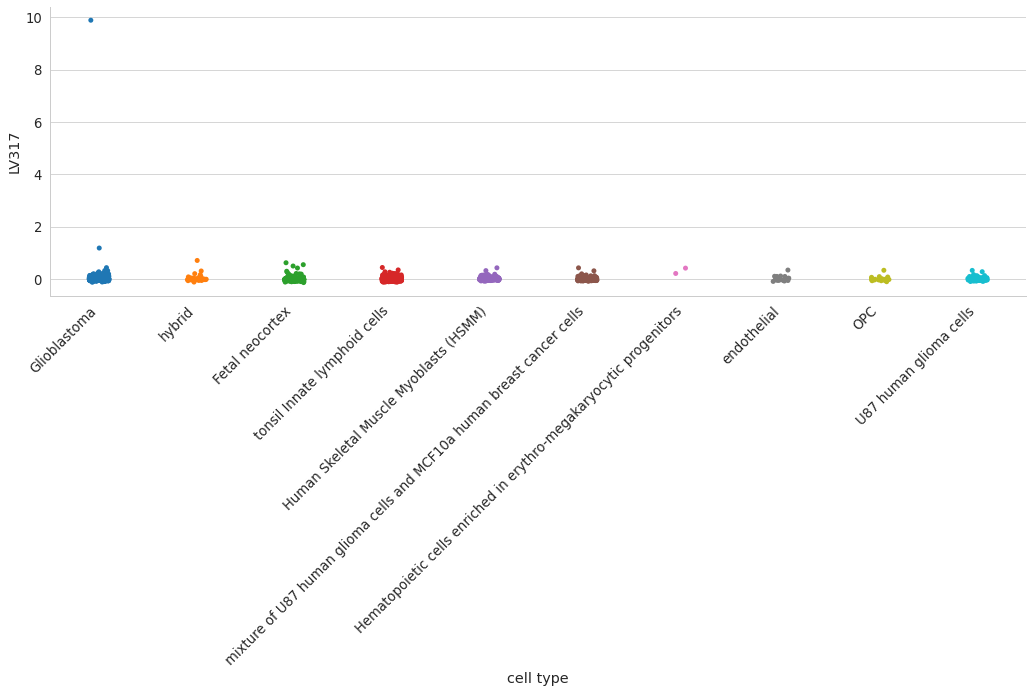

In [40]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [38]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("NOT CAT")
    ]
    display(_tmp.head(20))

tissue type      LV24
project   run                                  
SRP057087 SRR1970416  NOT CATEGORIZED  1.337396
          SRR1970420  NOT CATEGORIZED  1.328275
          SRR1970418  NOT CATEGORIZED  1.215959
          SRR1970398  NOT CATEGORIZED  1.156435
          SRR1970410  NOT CATEGORIZED  1.149749
          SRR1970412  NOT CATEGORIZED  1.145804
          SRR1970414  NOT CATEGORIZED  1.085125
          SRR1970402  NOT CATEGORIZED  1.026727
          SRR1970400  NOT CATEGORIZED  1.014584
          SRR1970406  NOT CATEGORIZED  0.964631
          SRR1970394  NOT CATEGORIZED  0.888795
          SRR1970411  NOT CATEGORIZED  0.872706
          SRR1970404  NOT CATEGORIZED  0.858728
          SRR1970396  NOT CATEGORIZED  0.852233
          SRR1970408  NOT CATEGORIZED  0.807428
          SRR1970417  NOT CATEGORIZED  0.774097
          SRR1970419  NOT CATEGORIZED  0.731714
          SRR1970405  NOT CATEGORIZED  0.638534
          SRR1970399  NOT CATEGORIZED  0.598748
          SRR1970395  NOT CATEGORIZED  0.597570

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057087, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP057087"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

patient  gender group      LV24
project   run                                       
SRP057087 SRR1970416      12  female    PN  1.337396
          SRR1970420      14  female    PN  1.328275
          SRR1970418      13  female    PN  1.215959
          SRR1970398       3    male    PN  1.156435
          SRR1970410       9    male    PN  1.149749
          SRR1970412      10    male    PN  1.145804
          SRR1970414      11  female    PN  1.085125
          SRR1970402       5    male    PN  1.026727
          SRR1970400       4  female    PN  1.014584
          SRR1970406       7    male    PN  0.964631
          SRR1970394       1    male    PN  0.888795
          SRR1970411      10    male    PP  0.872706
          SRR1970404       6  female    PN  0.858728
          SRR1970396       2    male    PN  0.852233
          SRR1970408       8    male    PN  0.807428
          SRR1970417      13  female    PP  0.774097
          SRR1970419      14  female    PP  0.731714
          SRR1970405       7    male    PP  0.638534
          SRR1970399       4  female    PP  0.598748
          SRR1970395       2    male    PP  0.597570
          SRR1970401       5    male    PP  0.552676
          SRR1970393       1    male    PP  0.529576
          SRR1970415      12  female    PP  0.515398
          SRR1970397       3    male    PP  0.497741
          SRR1970407       8    male    PP  0.476089
          SRR1970413      11  female    PP  0.390206
          SRR1970403       6  female    PP  0.311670
          SRR1970409       9    male    PP  0.194421

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.